# PatchCamelyon (PCam) — Dataset Investigation

Comprehensive exploration: file inventory, sizes, label distribution, metadata, data quality (anomalies, duplicates, blur, contrast, stain stats), and sample images.

## 1. Setup and paths

In [36]:
import os
import sys

# Project root = parent of 'notebooks' if we're in notebooks, else cwd
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'pcam-master'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = os.path.join(PROJECT_ROOT, 'pcam_data')
if not os.path.isdir(DATA_DIR) and os.path.isdir(os.path.join(os.getcwd(), 'pcam_data')):
    DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), 'pcam_data'))
print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Exists:", os.path.isdir(DATA_DIR))

Project root: c:\GP_ECG
Data dir: c:\GP_ECG\pcam_data
Exists: True


## 2. File inventory — names and sizes

In [37]:
def get_file_inventory(root_dir):
    """List all files under root_dir with sizes."""
    rows = []
    for dirpath, _, filenames in os.walk(root_dir):
        for f in filenames:
            path = os.path.join(dirpath, f)
            try:
                size = os.path.getsize(path)
            except OSError:
                size = None
            rel = os.path.relpath(path, root_dir)
            rows.append((rel, size))
    return rows

inv = get_file_inventory(DATA_DIR)
df_files = pd.DataFrame(inv, columns=['path', 'size_bytes'])
df_files['size_MB'] = (df_files['size_bytes'] / (1024**2)).round(2)
df_files['size_GB'] = (df_files['size_bytes'] / (1024**3)).round(2)
df_files = df_files.sort_values('path')

print("File inventory (all files under pcam_data):")
display(df_files)
print("\nTotal size:", f"{df_files['size_bytes'].sum() / (1024**3):.2f} GB")

File inventory (all files under pcam_data):


,path,size_bytes,size_MB,size_GB
0,test\camelyonpatch_level_2_split_test_meta.csv,1608584,1.53,0.00
1,test\camelyonpatch_level_2_split_test_x.h5,906040528,864.07,0.84
2,test\camelyonpatch_level_2_split_test_y.h5,34816,0.03,0.00
3,training\camelyonpatch_level_2_split_train_met...,15047830,14.35,0.01
4,training\camelyonpatch_level_2_split_train_x.h5,7248299800,6912.52,6.75
5,training\camelyonpatch_level_2_split_train_y.h5,264192,0.25,0.00
6,val\camelyonpatch_level_2_split_valid_meta.csv,1850810,1.77,0.00
7,val\camelyonpatch_level_2_split_valid_x.h5,906040528,864.07,0.84
8,val\camelyonpatch_level_2_split_valid_y.h5,34816,0.03,0.00



Total size: 8.46 GB


## 3. Load dataset and get dimensions

In [38]:
from keras_pcam.dataset.pcam import load_data

(train_x, train_y, meta_train), (valid_x, valid_y, meta_valid), (test_x, test_y, meta_test) = load_data(data_dir=DATA_DIR)

def summarize_split(name, x, y):
    n = len(x)
    sample = x[0]
    arr = np.array(sample)
    return {"split": name, "n_samples": n, "image_shape": arr.shape}

splits = [
    summarize_split("train", train_x, train_y),
    summarize_split("valid", valid_x, valid_y),
    summarize_split("test", test_x, test_y),
]
df_dims = pd.DataFrame(splits)
print("Dataset dimensions:")
display(df_dims)
print("\nImage shape (H, W, C):", splits[0]["image_shape"])

Dataset dimensions:


,split,n_samples,image_shape
0,train,262144,"(96, 96, 3)"
1,valid,32768,"(96, 96, 3)"
2,test,32768,"(96, 96, 3)"



Image shape (H, W, C): (96, 96, 3)


## 4. Label counts (class distribution)

In [39]:
def label_counts(y, name):
    flat = np.array(y).flatten()
    uniq, cnt = np.unique(flat, return_counts=True)
    return pd.DataFrame({"split": name, "label": uniq, "count": cnt})

counts = pd.concat([
    label_counts(train_y, "train"),
    label_counts(valid_y, "valid"),
    label_counts(test_y, "test"),
], ignore_index=True)

print("Label distribution (0 = negative, 1 = positive / metastatic):")
display(counts)

pivot = counts.pivot(index="split", columns="label", values="count")
pivot.columns = [f"class_{c}" for c in pivot.columns]
pivot["total"] = pivot.sum(axis=1)
pivot["pct_positive"] = (pivot.get("class_1", 0) / pivot["total"] * 100).round(1)
print("\nPer-split summary:")
display(pivot)

Label distribution (0 = negative, 1 = positive / metastatic):


,split,label,count
0,train,0,131072
1,train,1,131072
2,valid,0,16399
3,valid,1,16369
4,test,0,16391
5,test,1,16377



Per-split summary:


,class_0,class_1,total,pct_positive
split,,,,
test,16391,16377,32768,50.0
train,131072,131072,262144,50.0
valid,16399,16369,32768,50.0


## 5. Metadata tables (columns, dtypes, sample)

In [40]:
print("Train meta — columns and dtypes:")
print(meta_train.dtypes)
print("\nTrain meta — first 5 rows:")
display(meta_train.head())
print("\nTrain meta — shape:", meta_train.shape)
print("\nTrain meta — describe:")
display(meta_train.describe(include='all'))

Train meta — columns and dtypes:
Unnamed: 0             int64
coord_y                int64
coord_x                int64
tumor_patch             bool
center_tumor_patch      bool
wsi                   object
dtype: object

Train meta — first 5 rows:


,Unnamed: 0,coord_y,coord_x,tumor_patch,center_tumor_patch,wsi
0,0,63104,43648,False,False,camelyon16_train_tumor_104
1,1,148544,74048,True,True,camelyon16_train_tumor_003
2,2,64192,78912,True,True,camelyon16_train_tumor_089
3,3,98048,72128,True,True,camelyon16_train_tumor_004
4,4,27264,50688,False,False,camelyon16_train_normal_118



Train meta — shape: (262144, 6)

Train meta — describe:


,Unnamed: 0,coord_y,coord_x,tumor_patch,center_tumor_patch,wsi
count,262144.000000,262144.000000,262144.000000,262144,262144,262144
unique,NaN,NaN,NaN,2,2,216
top,NaN,NaN,NaN,True,False,camelyon16_train_tumor_093
freq,NaN,NaN,NaN,131745,131072,3800
mean,131071.500000,95677.708252,53043.446045,NaN,NaN,NaN
std,75674.598821,50768.330956,26705.645788,NaN,NaN,NaN
min,0.000000,0.000000,128.000000,NaN,NaN,NaN
25%,65535.750000,49920.000000,32896.000000,NaN,NaN,NaN
50%,131071.500000,97728.000000,49152.000000,NaN,NaN,NaN
75%,196607.250000,139328.000000,68736.000000,NaN,NaN,NaN


In [41]:
print("Valid meta — head:")
display(meta_valid.head())
print("Test meta — head:")
display(meta_test.head())

Valid meta — head:


,Unnamed: 0,coord_y,coord_x,tumor_patch,center_tumor_patch,wsi
0,0,26496,35136,True,True,camelyon16_train_tumor_085
1,1,96576,59520,True,True,camelyon16_train_tumor_069
2,2,19840,46848,True,True,camelyon16_train_tumor_097
3,3,38720,69440,True,True,camelyon16_train_tumor_082
4,4,22848,23424,True,True,camelyon16_train_tumor_082


Test meta — head:


,Unnamed: 0,coord_y,coord_x,tumor_patch,center_tumor_patch,wsi
0,0,145856,73984,False,False,camelyon16_test_032
1,1,92224,76032,True,True,camelyon16_test_029
2,2,14720,15936,False,False,camelyon16_test_055
3,3,20096,15360,True,True,camelyon16_test_071
4,4,34688,15936,True,True,camelyon16_test_071


## 6. Data quality report

Outliers (blank / high black–white ratio), exact duplicates, class balance from scan, per-channel color stats, blur and contrast. Run report once; then use the cells below to view and optionally save the report.

In [42]:
from __future__ import annotations
import hashlib
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
from scipy.ndimage import laplace
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kwargs):
        return it

# Use load_data from section 3 as PCam loader for quality report
pcam_load_data = load_data

CHUNK_SIZE = 2000
STD_ZERO_THRESHOLD = 1e-6
BLACK_WHITE_PIXEL_RATIO_THRESHOLD = 0.95
BLUR_LAPLACIAN_THRESHOLD = 1e-3
LOW_CONTRAST_STD_THRESHOLD = 5e-2
BACKGROUND_GRAY_THRESHOLD = 0.9
TISSUE_PCT_THRESHOLD = 0.2

In [43]:
def _detect_anomalies_and_duplicates(x_ds, chunk_size, std_threshold, bw_ratio_threshold, split_name):
    anomalies = []
    hash_list = []
    counts = {"zero_std": 0, "all_black": 0, "all_white": 0, "high_black_ratio": 0, "high_white_ratio": 0,
             "low_blur_score": 0, "low_contrast": 0, "low_tissue": 0}
    quality = {"n_images": 0, "blur": {"sum": 0.0, "sum_sq": 0.0, "min": None, "max": None},
               "gray_std": {"sum": 0.0, "sum_sq": 0.0, "min": None, "max": None},
               "channel_means": None, "channel_stds": None}
    n = len(x_ds)
    for start in tqdm(range(0, n, chunk_size), desc=f"{split_name} scan", unit="chunk"):
        end = min(start + chunk_size, n)
        batch = np.asarray(x_ds[start:end])
        for i in range(batch.shape[0]):
            idx = start + i
            img = batch[i]
            img = (img.astype(np.float64) / 255.0) if img.max() > 1 else img.astype(np.float64)
            std = float(np.std(img))
            mn, mx = float(np.min(img)), float(np.max(img))
            n_pixels = img.size
            ratio_black = np.sum(img <= 1/255.0) / n_pixels
            ratio_white = np.sum(img >= 254/255.0) / n_pixels
            # Relaxed ratios for display (match human perception: slide background often 0.9–0.98)
            ratio_white_relaxed = float(np.sum(img >= 0.9) / n_pixels)
            ratio_black_relaxed = float(np.sum(img <= 0.1) / n_pixels)
            gray = img.mean(axis=2)
            gray_std = float(np.std(gray))
            blur_score = float(np.var(laplace(gray)))
            tissue_pct = float(np.sum(gray < BACKGROUND_GRAY_THRESHOLD)) / n_pixels
            ch_means = img.mean(axis=(0,1))
            ch_stds = img.std(axis=(0,1))
            if quality["channel_means"] is None:
                quality["channel_means"] = {"sum": np.zeros_like(ch_means), "sum_sq": np.zeros_like(ch_means),
                    "min": np.full_like(ch_means, np.inf), "max": np.full_like(ch_means, -np.inf)}
                quality["channel_stds"] = {"sum": np.zeros_like(ch_stds), "sum_sq": np.zeros_like(ch_stds),
                    "min": np.full_like(ch_stds, np.inf), "max": np.full_like(ch_stds, -np.inf)}
            quality["n_images"] += 1
            quality["blur"]["sum"] += blur_score
            quality["blur"]["sum_sq"] += blur_score * blur_score
            quality["blur"]["min"] = blur_score if quality["blur"]["min"] is None else min(quality["blur"]["min"], blur_score)
            quality["blur"]["max"] = blur_score if quality["blur"]["max"] is None else max(quality["blur"]["max"], blur_score)
            quality["gray_std"]["sum"] += gray_std
            quality["gray_std"]["sum_sq"] += gray_std * gray_std
            quality["gray_std"]["min"] = gray_std if quality["gray_std"]["min"] is None else min(quality["gray_std"]["min"], gray_std)
            quality["gray_std"]["max"] = gray_std if quality["gray_std"]["max"] is None else max(quality["gray_std"]["max"], gray_std)
            cm, cs = quality["channel_means"], quality["channel_stds"]
            cm["sum"] += ch_means; cm["sum_sq"] += ch_means * ch_means
            cm["min"] = np.minimum(cm["min"], ch_means); cm["max"] = np.maximum(cm["max"], ch_means)
            cs["sum"] += ch_stds; cs["sum_sq"] += ch_stds * ch_stds
            cs["min"] = np.minimum(cs["min"], ch_stds); cs["max"] = np.maximum(cs["max"], ch_stds)
            reasons = []
            if std <= std_threshold: counts["zero_std"] += 1; reasons.append("zero_std")
            if mn >= 254/255 and mx >= 254/255: counts["all_white"] += 1; reasons.append("all_white")
            elif mn <= 1/255 and mx <= 1/255: counts["all_black"] += 1; reasons.append("all_black")
            else:
                if ratio_black >= bw_ratio_threshold: counts["high_black_ratio"] += 1; reasons.append("high_black_ratio")
                if ratio_white >= bw_ratio_threshold: counts["high_white_ratio"] += 1; reasons.append("high_white_ratio")
            if blur_score <= BLUR_LAPLACIAN_THRESHOLD: counts["low_blur_score"] += 1; reasons.append("low_blur_score")
            if gray_std <= LOW_CONTRAST_STD_THRESHOLD: counts["low_contrast"] += 1; reasons.append("low_contrast")
            if tissue_pct < TISSUE_PCT_THRESHOLD: counts["low_tissue"] += 1; reasons.append("low_tissue")
            if reasons:
                anomalies.append({"index": idx, "reasons": reasons, "std": round(std,6), "min": round(mn,4), "max": round(mx,4),
                    "ratio_black": round(ratio_black,4), "ratio_white": round(ratio_white,4),
                    "ratio_black_relaxed": round(ratio_black_relaxed,4), "ratio_white_relaxed": round(ratio_white_relaxed,4),
                    "gray_std": round(gray_std,6), "blur_score": round(blur_score,6), "tissue_pct": round(tissue_pct,4)})
            raw = batch[i].tobytes()
            hash_list.append((idx, hashlib.sha256(raw).hexdigest()))
    n_imgs = max(quality["n_images"], 1)
    q = {"n_images": quality["n_images"], "blur": {}, "gray_std": {}, "channel_means": {}, "channel_stds": {}}
    for key_src, key_dst, low_thr, low_key in [("blur", "blur", BLUR_LAPLACIAN_THRESHOLD, "low_blur_score"), ("gray_std", "gray_std", LOW_CONTRAST_STD_THRESHOLD, "low_contrast")]:
        st = quality[key_src]
        mean = st["sum"] / n_imgs
        var = max(st["sum_sq"] / n_imgs - mean * mean, 0.0)
        q[key_dst] = {"mean": float(mean), "std": float(np.sqrt(var)), "min": float(st["min"]) if st["min"] is not None else None,
            "max": float(st["max"]) if st["max"] is not None else None, "low_threshold": float(low_thr), "low_count": int(counts[low_key])}
    def _ch(c):
        if c is None: return {}
        s, s2, mn, mx = c["sum"], c["sum_sq"], c["min"], c["max"]
        mean = s / n_imgs
        var = np.maximum(s2 / n_imgs - mean * mean, 0.0)
        return {"global_mean": [float(v) for v in mean], "global_std": [float(v) for v in np.sqrt(var)], "min": [float(v) for v in mn], "max": [float(v) for v in mx]}
    q["channel_means"] = _ch(quality["channel_means"])
    q["channel_stds"] = _ch(quality["channel_stds"])
    return anomalies, hash_list, counts, q

def _find_duplicate_groups(hash_list):
    h2i = defaultdict(list)
    for idx, h in hash_list:
        h2i[h].append(idx)
    return [sorted(indices) for indices in h2i.values() if len(indices) > 1]

def run_report(data_dir, chunk_size=CHUNK_SIZE, std_threshold=STD_ZERO_THRESHOLD, bw_ratio_threshold=BLACK_WHITE_PIXEL_RATIO_THRESHOLD, save_anomaly_indices=True):
    data_dir = Path(data_dir)
    if not data_dir.is_dir():
        raise FileNotFoundError(f"Data directory not found: {data_dir}")
    if pcam_load_data is None:
        raise ImportError("PCam loader not available. Ensure pcam-master exists and dependencies are installed.")
    (train_x, train_y, meta_train), (valid_x, valid_y, meta_valid), (test_x, test_y, meta_test) = pcam_load_data(data_dir=str(data_dir))
    splits_data = {"train": (train_x, train_y, meta_train), "valid": (valid_x, valid_y, meta_valid), "test": (test_x, test_y, meta_test)}
    report = {"data_dir": str(data_dir), "splits": {}, "summary": {}}
    for split in ("train", "valid", "test"):
        x_ds, y_ds, meta = splits_data[split]
        y = np.asarray(y_ds).flatten()
        n_total, n_pos = y.shape[0], int(np.sum(y))
        n_neg = n_total - n_pos
        imbalance_ratio = (n_neg / n_pos) if n_pos > 0 else float("inf")
        split_report = {"n_samples": n_total, "class_counts": {"negative": n_neg, "positive": n_pos}, "imbalance_ratio_neg_pos": round(imbalance_ratio, 4),
            "anomaly_counts": {}, "n_anomalous": 0, "anomaly_indices": [], "n_duplicate_groups": 0, "n_images_in_duplicate_groups": 0, "duplicate_groups_sample": []}
        anomalies, hash_list, anomaly_counts, quality = _detect_anomalies_and_duplicates(x_ds, chunk_size, std_threshold, bw_ratio_threshold, split)
        split_report["anomaly_counts"] = anomaly_counts
        split_report["n_anomalous"] = len(anomalies)
        if save_anomaly_indices and anomalies:
            split_report["anomaly_indices"] = [a["index"] for a in anomalies]
            split_report["anomaly_details"] = [{"index": a["index"], "reasons": a["reasons"], "ratio_black": a["ratio_black"], "ratio_white": a["ratio_white"], "ratio_black_relaxed": a.get("ratio_black_relaxed"), "ratio_white_relaxed": a.get("ratio_white_relaxed")} for a in anomalies]
            split_report["anomaly_details_sample"] = anomalies[:20]
        dup_groups = _find_duplicate_groups(hash_list)
        split_report["n_duplicate_groups"] = len(dup_groups)
        split_report["n_images_in_duplicate_groups"] = sum(len(g) for g in dup_groups)
        if dup_groups: split_report["duplicate_groups_sample"] = dup_groups[:15]
        split_report["quality"] = quality
        if meta is not None: split_report["meta_shape"] = list(meta.shape); split_report["meta_columns"] = list(meta.columns)
        report["splits"][split] = split_report
    report["summary"] = {"total_train": report["splits"].get("train",{}).get("n_samples"), "total_valid": report["splits"].get("valid",{}).get("n_samples"),
        "total_test": report["splits"].get("test",{}).get("n_samples"), "train_imbalance_ratio": report["splits"].get("train",{}).get("imbalance_ratio_neg_pos"),
        "train_anomalous": report["splits"].get("train",{}).get("n_anomalous"), "train_duplicate_images": report["splits"].get("train",{}).get("n_images_in_duplicate_groups")}
    return report

In [44]:
# Compute the full report once (run after sections 1–3 and the quality setup/helper cells above)
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")

report = run_report(DATA_DIR, chunk_size=CHUNK_SIZE, save_anomaly_indices=True)

print("Report computed. Splits:", list(report["splits"].keys()))

test scan: 100%|██████████| 17/17 [01:34<00:00,  5.58s/chunk]

Report computed. Splits: ['train', 'valid', 'test']


### 6.1 (Optional) Save full report to JSON

In [45]:
out_path = os.path.join(PROJECT_ROOT, "reports", "pcam_data_quality_report.json")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
with open(out_path, "w") as f:
    json.dump(report, f, indent=2)
print("Full report saved to:", out_path)

Full report saved to: c:\GP_ECG\reports\pcam_data_quality_report.json


### 6.1b Retracing anomalies: load and use saved indices

The report stores **per split**:
- **`anomaly_indices`**: full list of integer indices (positions in that split’s array).
- **`anomaly_details`**: for every anomaly, `{"index": i, "reasons": [...], "ratio_black", "ratio_white", "ratio_black_relaxed", "ratio_white_relaxed"}`. **Strict** `ratio_white`/`ratio_black` use pixel thresholds 254/255 and 1/255. **Relaxed** (`ratio_white_relaxed`, `ratio_black_relaxed`) use ≥0.9 and ≤0.1 so they match what you see (e.g. slide background). The viz shows relaxed W/B; use either for your own thresholds.

When you save the report to JSON (cell above), the same structure is on disk. Use the cell below to load the report and build index sets for exclusion or filtering.

In [46]:
# Load report from JSON (if you saved it) or use in-memory report from "Run report" cell
_report_path = os.path.join(PROJECT_ROOT, "reports", "pcam_data_quality_report.json")
_r = None
try:
    _r = report
except NameError:
    pass
if _r is None and os.path.isfile(_report_path):
    with open(_report_path) as f:
        _r = json.load(f)
if _r is None:
    raise RuntimeError("Run the 'Run report' cell and optionally save the report to JSON first.")

# Example: get all anomaly indices for train (to exclude from training)
train_anomaly_indices = set(_r["splits"]["train"].get("anomaly_indices", []))
print("Train anomaly indices (count):", len(train_anomaly_indices))

# Example: get only blank-like indices (zero_std, all_black, all_white, high_white_ratio)
blank_reasons = {"zero_std", "all_black", "all_white", "high_white_ratio"}
train_details = _r["splits"]["train"].get("anomaly_details", [])
train_blank_like_indices = [d["index"] for d in train_details if any(r in blank_reasons for r in d["reasons"])]
print("Train blank-like indices (count):", len(train_blank_like_indices))

# Example: filter by white/black level (set your threshold later)
# max_allowed_white = 0.95  # exclude patches with ratio_white above this
# max_allowed_black = 0.95
# train_high_white = [d["index"] for d in train_details if d.get("ratio_white", 0) > max_allowed_white]
# train_high_black = [d["index"] for d in train_details if d.get("ratio_black", 0) > max_allowed_black]

# Example: use in training — exclude anomalous indices when building batches
# valid_mask = np.ones(len(train_y), dtype=bool)
# valid_mask[list(train_anomaly_indices)] = False
# then index train_x, train_y with valid_mask (e.g. train_x[valid_mask])

Train anomaly indices (count): 41579
Train blank-like indices (count): 9


### 6.2 Class balance (from quality report)

Label distribution and imbalance ratio per split from the quality scan.

In [47]:
rows = []
for split in ("train", "valid", "test"):
    s = report["splits"].get(split, {})
    if not s or "class_counts" not in s:
        continue
    rows.append({
        "split": split,
        "neg": s["class_counts"]["negative"],
        "pos": s["class_counts"]["positive"],
        "total": s["n_samples"],
        "neg_pos_ratio": s["imbalance_ratio_neg_pos"],
    })

pd.DataFrame(rows)

,split,neg,pos,total,neg_pos_ratio
0,train,131072,131072,262144,1.0000
1,valid,16399,16369,32768,1.0018
2,test,16391,16377,32768,1.0009


### 6.3 Visualize near-blank outliers

Example patches flagged as blank-like (zero_std, all_black, all_white, high_white_ratio) and a sample of other anomalous indices.

No blank-like outliers in the first 20 anomaly details or first 200 indices. Showing first 12 anomaly indices for manual inspection.


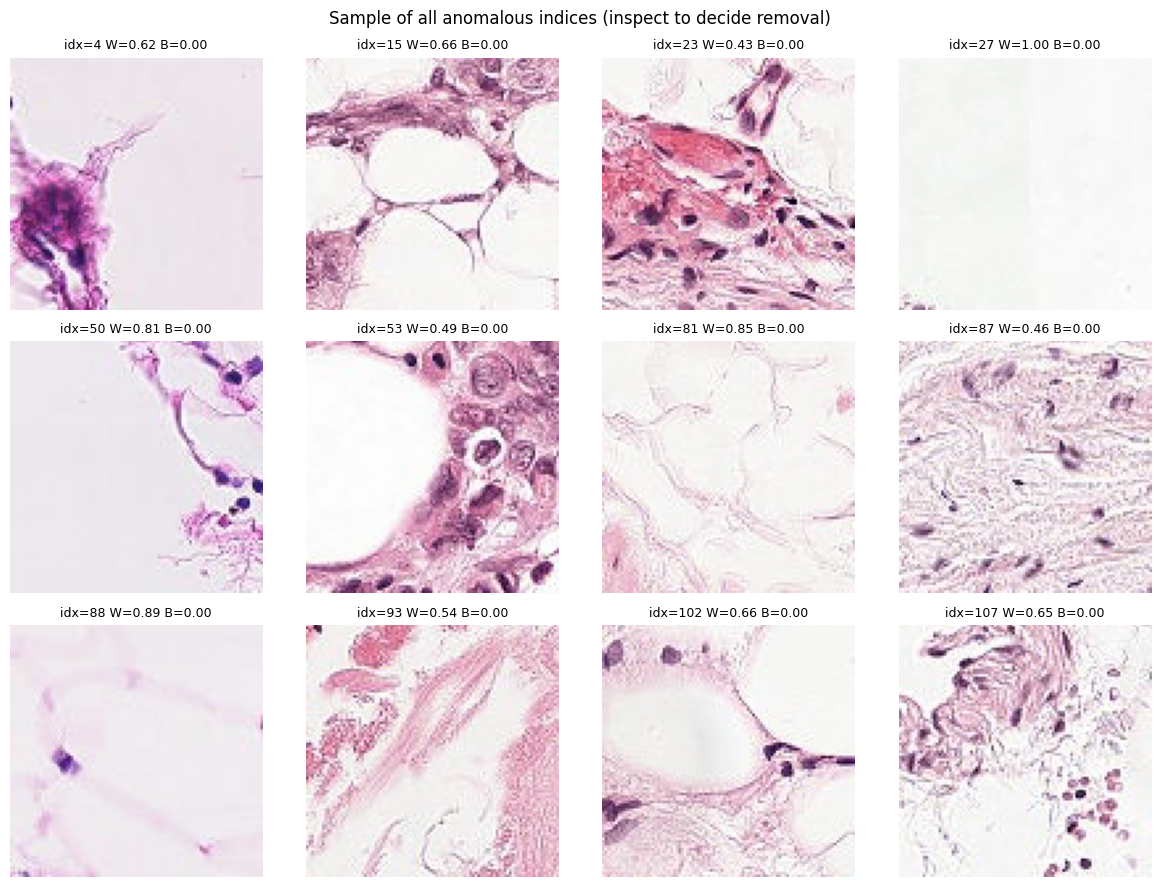

In [48]:
# Use report from memory, or load from file if this cell is run standalone
_report = None
try:
    _report = report
except NameError:
    pass
_report_path = os.path.join(PROJECT_ROOT, "reports", "pcam_data_quality_report.json")
if _report is None and os.path.isfile(_report_path):
    with open(_report_path) as f:
        _report = json.load(f)
if _report is None:
    raise RuntimeError("Run the 'Run report' cell above first, or save the report to reports/pcam_data_quality_report.json")
try:
    _ = train_x
except NameError:
    (train_x, _, _), _, _ = load_data(data_dir=DATA_DIR)

blank_reasons = {"zero_std", "all_black", "all_white", "high_white_ratio"}
details = _report["splits"]["train"].get("anomaly_details_sample", [])
blank_like = [a for a in details if any(r in blank_reasons for r in a["reasons"])]
all_anomaly_indices = _report["splits"]["train"].get("anomaly_indices", [])[:12]
# Lookup index -> {ratio_white, ratio_black} for showing W/B in titles
all_details = _report["splits"]["train"].get("anomaly_details", [])
idx_to_detail = {d["index"]: d for d in all_details}

def _ratio_label(d):
    # Use relaxed ratios (white ≥0.9, black ≤0.1) so W/B match what you see; fallback to strict for old reports
    w = d.get("ratio_white_relaxed") if d.get("ratio_white_relaxed") is not None else d.get("ratio_white")
    b = d.get("ratio_black_relaxed") if d.get("ratio_black_relaxed") is not None else d.get("ratio_black")
    return f" W={w:.2f} B={b:.2f}" if (w is not None and b is not None) else ""

def show_grid(indices, titles, title_prefix="", max_show=12):
    n = min(len(indices), max_show)
    if n == 0:
        return
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = axes.flatten()
    for i in range(n):
        idx = indices[i]
        img = np.asarray(train_x[idx])
        if img.max() > 1:
            img = img / 255.0
        axes[i].imshow(img)
        axes[i].set_title(titles[i] if i < len(titles) else str(idx), fontsize=9)
        axes[i].set_axis_off()
    for j in range(n, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title_prefix, fontsize=12)
    plt.tight_layout()
    plt.show()

if blank_like:
    show_grid([a["index"] for a in blank_like], [", ".join(a["reasons"]) + f" (idx={a['index']})" + _ratio_label(a) for a in blank_like],
              title_prefix="Near-blank outliers (zero_std / all_black / all_white / high_white_ratio)", max_show=12)
else:
    candidates = _report["splits"]["train"].get("anomaly_indices", [])[:200]
    blank_indices = []
    for idx in candidates:
        img = np.asarray(train_x[idx]).astype(np.float64)
        if img.max() > 1:
            img = img / 255.0
        std, mn, mx = np.std(img), np.min(img), np.max(img)
        if std < 1e-5 or (mn >= 0.99 and mx >= 0.99) or (mn <= 0.01 and mx <= 0.01):
            blank_indices.append(idx)
        if len(blank_indices) >= 12:
            break
    if blank_indices:
        show_grid(blank_indices, [f"idx={i}" + _ratio_label(idx_to_detail.get(i, {})) for i in blank_indices],
                  title_prefix="Near-blank outliers (from first 200 anomaly indices)", max_show=12)
    else:
        print("No blank-like outliers in the first 20 anomaly details or first 200 indices. Showing first 12 anomaly indices for manual inspection.")

if all_anomaly_indices:
    show_grid(all_anomaly_indices, [f"idx={i}" + _ratio_label(idx_to_detail.get(i, {})) for i in all_anomaly_indices],
              title_prefix="Sample of all anomalous indices (inspect to decide removal)", max_show=12)

### 6.4 Outlier / anomaly counts

Counts of images flagged as blank, nearly blank, high black/white ratio, very blurry, low-contrast, or low tissue content.

In [49]:
rows = []
for split in ("train", "valid", "test"):
    s = report["splits"].get(split, {})
    if not s or "anomaly_counts" not in s:
        continue
    ac = s["anomaly_counts"]
    rows.append({
        "split": split,
        **{k: ac.get(k, 0) for k in [
            "zero_std", "all_black", "all_white", "high_black_ratio", "high_white_ratio",
            "low_blur_score", "low_contrast", "low_tissue",
        ]},
        "total_flagged": s["n_anomalous"],
    })

pd.DataFrame(rows)

,split,zero_std,all_black,all_white,high_black_ratio,high_white_ratio,low_blur_score,low_contrast,low_tissue,total_flagged
0,train,4,2,2,0,5,1373,2768,40157,41579
1,valid,0,0,0,0,0,162,342,4705,4907
2,test,0,0,0,0,2,213,470,3904,4227


### 6.5 Duplicate images

Exact pixel-wise duplicate groups and number of images involved per split.

In [50]:
rows = []
for split in ("train", "valid", "test"):
    s = report["splits"].get(split, {})
    if not s:
        continue
    rows.append({
        "split": split,
        "n_duplicate_groups": s.get("n_duplicate_groups", 0),
        "n_images_in_duplicate_groups": s.get("n_images_in_duplicate_groups", 0),
    })

pd.DataFrame(rows)

,split,n_duplicate_groups,n_images_in_duplicate_groups
0,train,15235,57354
1,valid,2181,6841
2,test,1792,5177


### 6.6 Color / stain statistics (per-channel)

Per-channel global means/stds and ranges for color and stain normalization across splits.

In [51]:
def summarize_channels(split_report):
    q = split_report.get("quality", {})
    cm = q.get("channel_means", {})
    cs = q.get("channel_stds", {})
    return {
        "means_global_mean": cm.get("global_mean"),
        "means_min": cm.get("min"),
        "means_max": cm.get("max"),
        "stds_global_mean": cs.get("global_mean"),
        "stds_min": cs.get("min"),
        "stds_max": cs.get("max"),
    }

rows = []
for split in ("train", "valid", "test"):
    s = report["splits"].get(split, {})
    if not s:
        continue
    row = {"split": split}
    row.update(summarize_channels(s))
    rows.append(row)

pd.DataFrame(rows)

,split,means_global_mean,means_min,means_max,stds_global_mean,stds_min,stds_max
0,train,"[0.7007560017533195, 0.5383578037628156, 0.691...","[0.0, 0.0, 0.0]","[1.0, 1.0, 1.0]","[0.18174392258882913, 0.20083655163676134, 0.1...","[0.0, 0.0, 0.0]","[0.43847323082199785, 0.4357483576180141, 0.43..."
1,valid,"[0.6974725413296843, 0.534803252749984, 0.6880...","[0.12269624863834716, 0.046824363425923915, 0....","[0.988845486111025, 0.9881999761709821, 0.9881...","[0.18732773498147406, 0.20535075306818426, 0.1...","[0.0027707431394846677, 0.0030241337786568, 0....","[0.45814862370977893, 0.3845935616851645, 0.43..."
2,test,"[0.6792562782634923, 0.5210844083549313, 0.693...","[0.0563419117647066, 0.036572797521789595, 0.0...","[0.9980473005174214, 0.9959418402777731, 0.996...","[0.18567679448277064, 0.20209609107129559, 0.1...","[0.001782372947557801, 0.001782372947558104, 0...","[0.43119446109801524, 0.40570499967492135, 0.4..."


### 6.7 Image quality: blur and grayscale contrast

Global blur and grayscale-std statistics and how many patches fall below the thresholds.

In [52]:
rows = []
for split in ("train", "valid", "test"):
    s = report["splits"].get(split, {})
    if not s:
        continue
    q = s.get("quality", {})
    blur = q.get("blur", {})
    gray = q.get("gray_std", {})
    rows.append({
        "split": split,
        "blur_mean": blur.get("mean"),
        "blur_std": blur.get("std"),
        "blur_min": blur.get("min"),
        "blur_max": blur.get("max"),
        "blur_low_count": blur.get("low_count"),
        "gray_mean": gray.get("mean"),
        "gray_std": gray.get("std"),
        "gray_min": gray.get("min"),
        "gray_max": gray.get("max"),
        "gray_low_contrast_count": gray.get("low_count"),
    })

pd.DataFrame(rows)

,split,blur_mean,blur_std,blur_min,blur_max,blur_low_count,gray_mean,gray_std,gray_min,gray_max,gray_low_contrast_count
0,train,0.192125,0.101768,0.000000,0.648367,1373,0.180158,0.049340,0.000000,0.432078,2768
1,valid,0.196480,0.099057,0.000007,0.534871,162,0.185297,0.051087,0.002187,0.416182,342
2,test,0.172196,0.101489,0.000007,0.579988,213,0.180521,0.049929,0.001782,0.403744,470


## 7. Sample images (positive vs negative)

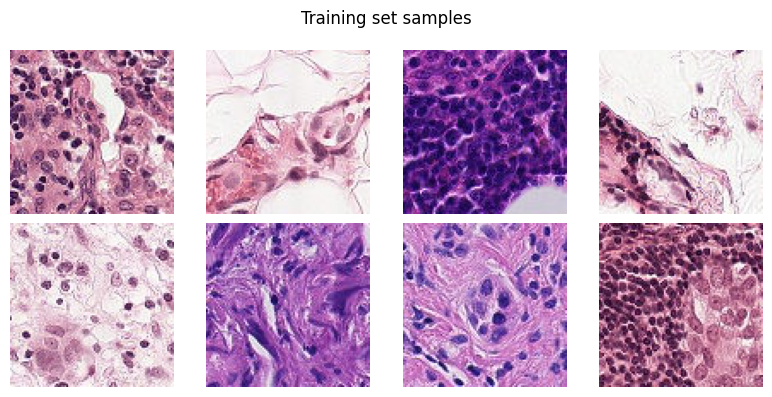

In [53]:
def show_samples(x, y, n_per_class=4, title="Samples"):
    y_flat = np.array(y).flatten()
    idx_0 = np.where(y_flat == 0)[0]
    idx_1 = np.where(y_flat == 1)[0]
    np.random.seed(42)
    pick_0 = np.random.choice(idx_0, size=min(n_per_class, len(idx_0)), replace=False)
    pick_1 = np.random.choice(idx_1, size=min(n_per_class, len(idx_1)), replace=False)
    fig, axes = plt.subplots(2, n_per_class, figsize=(2 * n_per_class, 4))
    for i, (ax_row, picks, label) in enumerate(zip(axes, [pick_0, pick_1], ["Negative (0)", "Positive (1)"])):
        for j, idx in enumerate(picks):
            img = np.asarray(x[idx])
            if img.max() > 1:
                img = img / 255.0
            ax_row[j].imshow(img)
            ax_row[j].set_axis_off()
        ax_row[0].set_ylabel(label, fontsize=10)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(train_x, train_y, n_per_class=4, title="Training set samples")

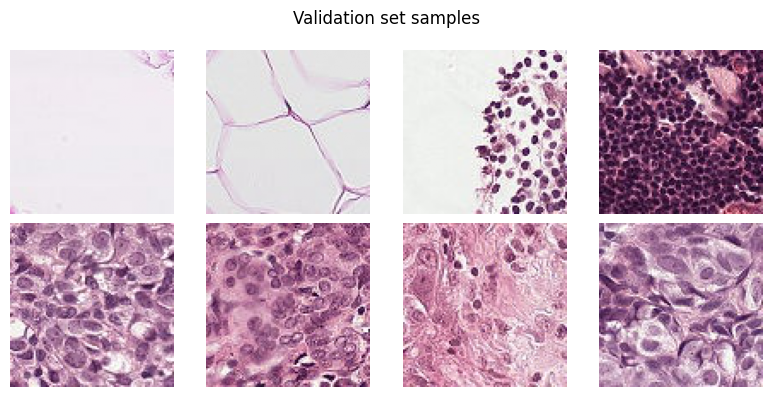

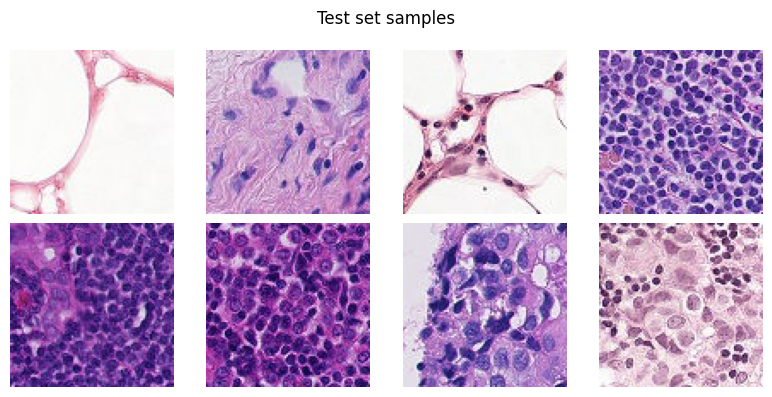

In [54]:
show_samples(valid_x, valid_y, n_per_class=4, title="Validation set samples")
show_samples(test_x, test_y, n_per_class=4, title="Test set samples")

## 8. Summary

In [55]:
print("=== PCam dataset summary ===")
print("Data root:", DATA_DIR)
print("Splits: train / valid / test")
print("Train:", len(train_x), "samples")
print("Valid:", len(valid_x), "samples")
print("Test:", len(test_x), "samples")
print("Image shape:", np.array(train_x[0]).shape)
print("Labels: binary (0 = no metastasis, 1 = metastasis in center 32x32)")
print("Meta: slide/origin info per patch (see meta_* DataFrames above).")

=== PCam dataset summary ===
Data root: c:\GP_ECG\pcam_data
Splits: train / valid / test
Train: 262144 samples
Valid: 32768 samples
Test: 32768 samples
Image shape: (96, 96, 3)
Labels: binary (0 = no metastasis, 1 = metastasis in center 32x32)
Meta: slide/origin info per patch (see meta_* DataFrames above).
